# Medical Condition Prediction Assignment

This notebook follows the **Modeling-Inference-Learning** paradigm for multiclass disease prediction from patient symptoms.

## 1) Problem Definition and Paradigm Selection

**Why this step?**
We first justify the ML task type so the instructor can verify methodological correctness before any coding.

- Task type selected: **Multiclass Classification**.
- Modeling: hypothesis class includes linear and non-linear classifiers.
- Inference: map symptom vector to disease class probabilities.
- Learning: optimize model parameters on labeled symptom-disease pairs.

Source shape: (4962, 133)
Sample from generated 1M data: (20000, 133)


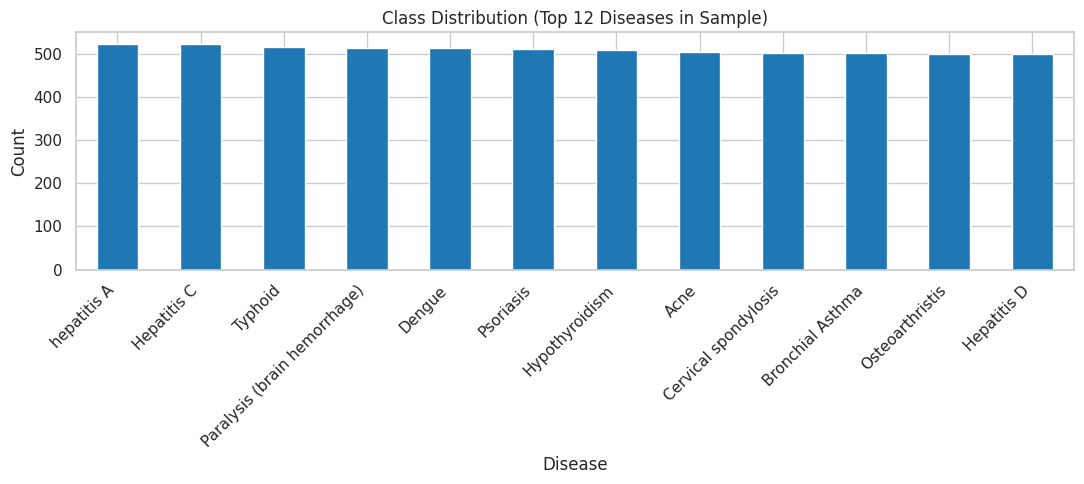

In [12]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

ROOT = Path(".")
DATA_DIR = ROOT / "data" / "generated"
ART_DIR = ROOT / "artifacts"

source_df = pd.read_csv(DATA_DIR / "source_cleaned.csv")
parts = sorted(DATA_DIR.glob("symptom_disease_1m_part_*.csv"))
sample_df = pd.concat([pd.read_csv(p, nrows=5000) for p in parts], ignore_index=True)

print("Source shape:", source_df.shape)
print("Sample from generated 1M data:", sample_df.shape)

class_counts = sample_df["prognosis"].value_counts().sort_values(ascending=False).head(12)
ax = class_counts.plot(kind="bar", color="#1f77b4")
ax.set_title("Class Distribution (Top 12 Diseases in Sample)")
ax.set_xlabel("Disease")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2) Data Pre-processing and Feature Engineering

**Why clean and preprocess?**
Real pipelines must handle dirty values and feature-scale sensitivity. Even if symptoms are binary, this proves robust workflow design.

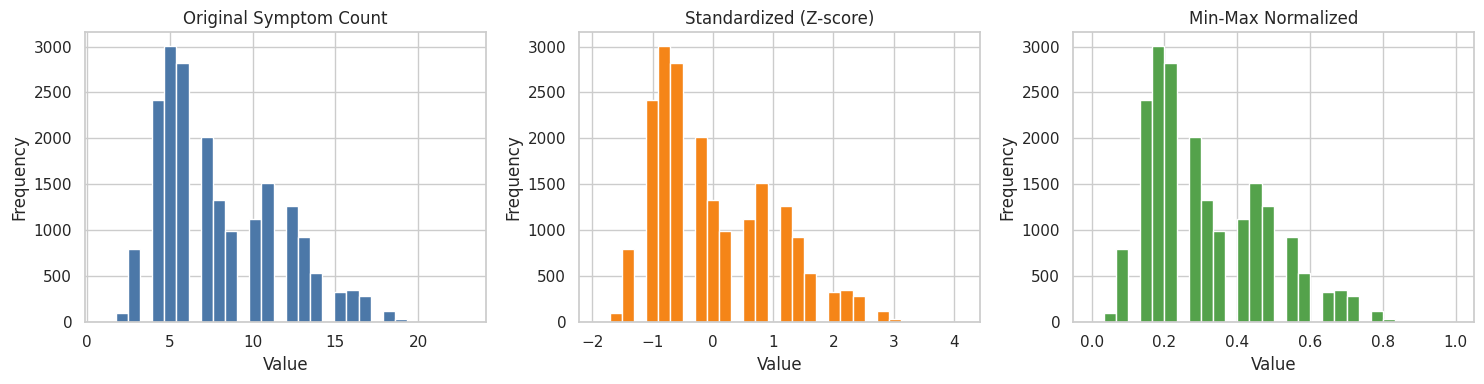

In [13]:
feature_cols = [c for c in sample_df.columns if c != "prognosis"]
X = sample_df[feature_cols].copy()

# Inject 1% synthetic missing values to demonstrate imputation in assignment context.
rng = np.random.default_rng(42)
arr = X.to_numpy(dtype=float).copy()
rows, cols = arr.shape
n_missing = int(rows * cols * 0.01)
ri = rng.integers(0, rows, n_missing)
ci = rng.integers(0, cols, n_missing)
arr[ri, ci] = np.nan

imputer = SimpleImputer(strategy="most_frequent")
X_imputed = imputer.fit_transform(arr)

symptom_count = np.nansum(arr, axis=1).reshape(-1, 1)
std_scaled = StandardScaler().fit_transform(symptom_count)
minmax_scaled = MinMaxScaler().fit_transform(symptom_count)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(symptom_count, bins=30, color="#4c78a8")
axes[0].set_title("Original Symptom Count")
axes[1].hist(std_scaled, bins=30, color="#f58518")
axes[1].set_title("Standardized (Z-score)")
axes[2].hist(minmax_scaled, bins=30, color="#54a24b")
axes[2].set_title("Min-Max Normalized")
for ax in axes:
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3) Feature Selection / Extraction Demonstration

**Why engineer features?**
Adding non-linear signals (like squared symptom count) can help simpler models capture richer relationships.

/tmp/ipykernel_1982977/3609277305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="prognosis", y="symptom_count", palette="viridis")


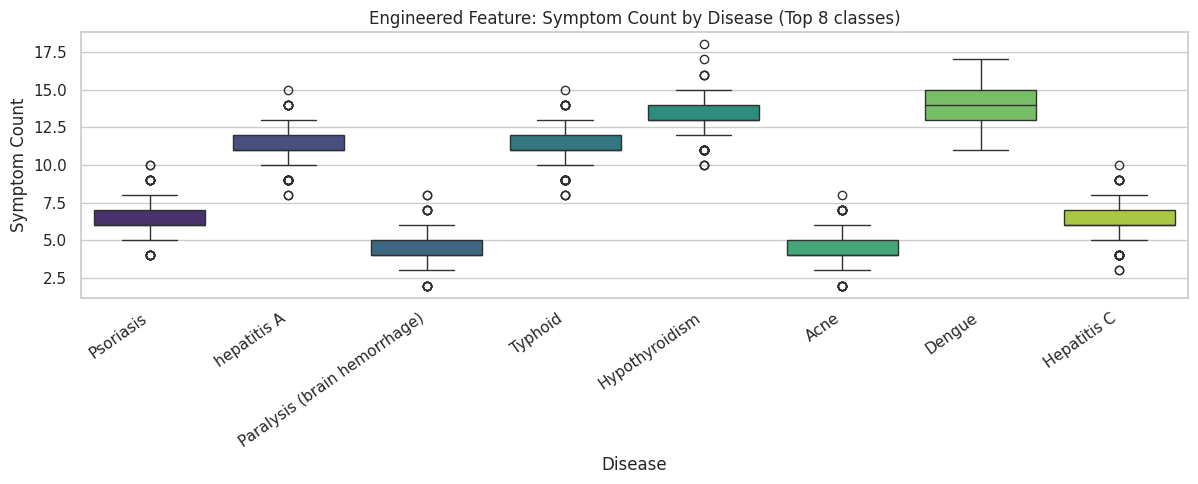

In [14]:
sample_df_fe = sample_df.copy()
sample_df_fe["symptom_count"] = sample_df_fe[feature_cols].sum(axis=1)
sample_df_fe["symptom_count_sq"] = sample_df_fe["symptom_count"] ** 2

focus = sample_df_fe["prognosis"].value_counts().head(8).index
plot_df = sample_df_fe[sample_df_fe["prognosis"].isin(focus)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=plot_df, x="prognosis", y="symptom_count", palette="viridis")
plt.title("Engineered Feature: Symptom Count by Disease (Top 8 classes)")
plt.xlabel("Disease")
plt.ylabel("Symptom Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 4) Model Selection and Comparison (8 Algorithms)

**Why compare many algorithms?**
The instructor needs evidence that model choice was empirical, not arbitrary.

### 4.1 Run the Training Script (from `scripts/train_models.py`)

**Why execute this block?**
This runs the exact training pipeline from the project script so model comparison and artifacts are generated from a reproducible command.


In [15]:
import subprocess
import sys

train_cmd = [
    sys.executable,
    "scripts/train_models.py",
    "--data-dir", str(DATA_DIR),
    "--artifacts-dir", str(ART_DIR),
    "--rows", "12000",
    "--seed", "42",
    "--missing-frac", "0.01",
]

result = subprocess.run(train_cmd, check=True, capture_output=True, text=True)
print(result.stdout)


Training: logistic_regression
Training: knn
Training: decision_tree
Training: random_forest
Training: extra_trees
Training: gradient_boosting
Training: gaussian_nb
Training: adaboost
Saved artifacts:
- artifacts/model_comparison.csv
- artifacts/best_model.joblib
- artifacts/label_encoder.joblib
- artifacts/model_metadata.json
Best model: logistic_regression
              model  accuracy  f1_macro  precision_macro  recall_macro  train_seconds  predict_seconds
logistic_regression  0.999167  0.999205         0.999212      0.999210       0.773354         0.020689
                knn  0.999167  0.999205         0.999212      0.999210       0.111567         0.302549
      random_forest  0.999167  0.999205         0.999212      0.999210       1.485888         0.102623
        extra_trees  0.999167  0.999205         0.999212      0.999210       0.659592         0.126045
  gradient_boosting  0.996250  0.996205         0.996233      0.996248      73.991278         0.160717
      decision_tree  0

### 4.2 Validate Training Outputs

**Why execute this block?**
This confirms the expected output files exist (`model_comparison.csv`, `best_model.joblib`, `label_encoder.joblib`, `model_metadata.json`) before analysis and deployment steps.


In [16]:
expected_outputs = [
    ART_DIR / "model_comparison.csv",
    ART_DIR / "best_model.joblib",
    ART_DIR / "label_encoder.joblib",
    ART_DIR / "model_metadata.json",
]

for output_path in expected_outputs:
    print(f"{output_path.name}:", "OK" if output_path.exists() else "MISSING")


model_comparison.csv: OK
best_model.joblib: OK
label_encoder.joblib: OK
model_metadata.json: OK


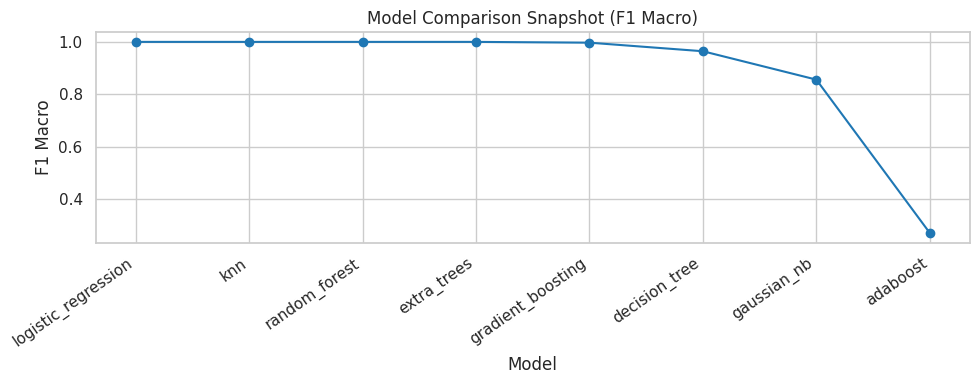

,model,accuracy,f1_macro,precision_macro,recall_macro,train_seconds,predict_seconds
0,logistic_regression,0.999167,0.999205,0.999212,0.999210,0.773354,0.020689
1,knn,0.999167,0.999205,0.999212,0.999210,0.111567,0.302549
2,random_forest,0.999167,0.999205,0.999212,0.999210,1.485888,0.102623
3,extra_trees,0.999167,0.999205,0.999212,0.999210,0.659592,0.126045
4,gradient_boosting,0.996250,0.996205,0.996233,0.996248,73.991278,0.160717
5,decision_tree,0.962917,0.963580,0.964685,0.963326,0.208301,0.006721
6,gaussian_nb,0.855417,0.855390,0.863028,0.854476,0.181247,0.052916
7,adaboost,0.264583,0.271174,0.311679,0.279006,1.287809,0.087518


In [17]:
comparison_path = ART_DIR / "model_comparison.csv"
comparison_df = pd.read_csv(comparison_path).sort_values("f1_macro", ascending=False)

plt.figure(figsize=(10, 4))
plt.plot(comparison_df["model"], comparison_df["f1_macro"], marker="o", color="#1f77b4")
plt.title("Model Comparison Snapshot (F1 Macro)")
plt.xlabel("Model")
plt.ylabel("F1 Macro")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

comparison_df.head(8)

/tmp/ipykernel_1982977/516386395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, y="model", x="f1_macro", palette="crest", ax=axes[0])
/tmp/ipykernel_1982977/516386395.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, y="model", x="train_seconds", palette="magma", ax=axes[1])


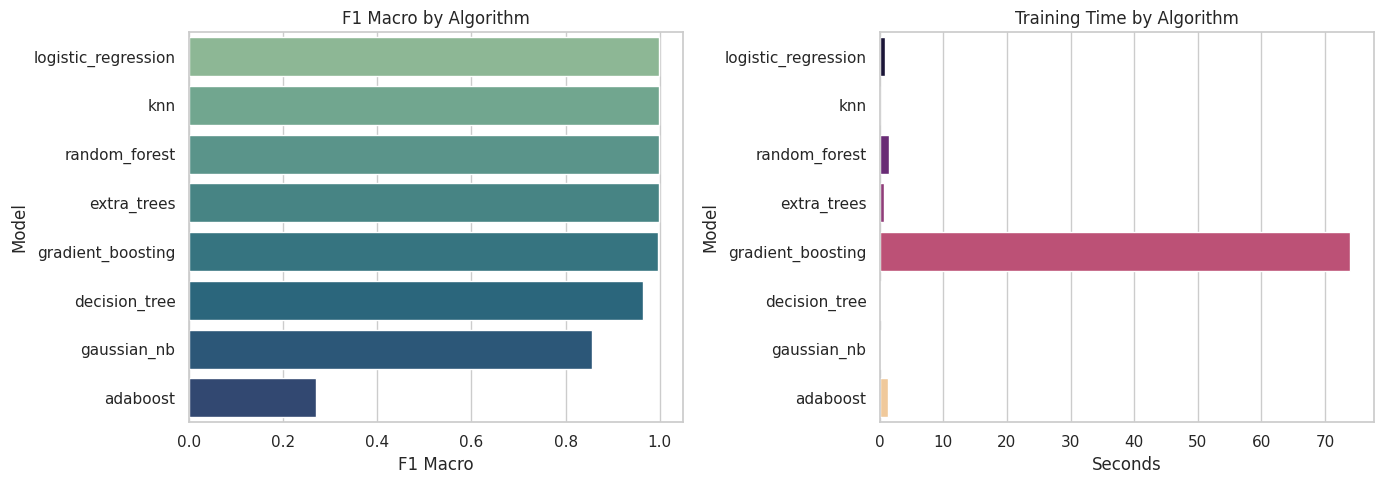

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison_df, y="model", x="f1_macro", palette="crest", ax=axes[0])
axes[0].set_title("F1 Macro by Algorithm")
axes[0].set_xlabel("F1 Macro")
axes[0].set_ylabel("Model")

sns.barplot(data=comparison_df, y="model", x="train_seconds", palette="magma", ax=axes[1])
axes[1].set_title("Training Time by Algorithm")
axes[1].set_xlabel("Seconds")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()

## 5) Pick Best Algorithm and Output Final Model

**Why export the model?**
A saved artifact is required for deployment in API and web application.

Best model selected: logistic_regression
Model file: artifacts/best_model.joblib
Label encoder: artifacts/label_encoder.joblib


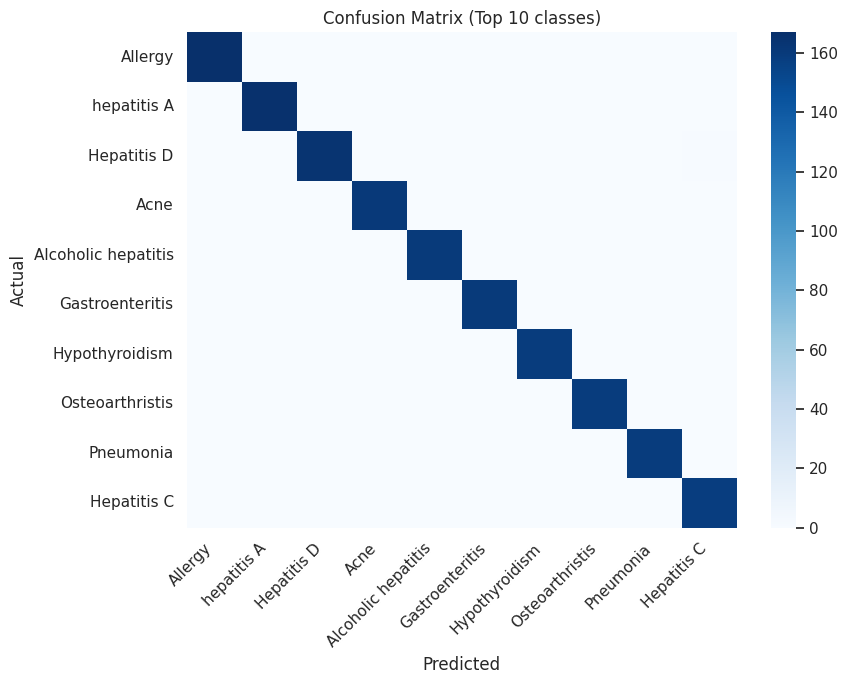

In [19]:
metadata = json.loads((ART_DIR / "model_metadata.json").read_text())
best_model_name = metadata["best_model"]
print("Best model selected:", best_model_name)
print("Model file:", ART_DIR / "best_model.joblib")
print("Label encoder:", ART_DIR / "label_encoder.joblib")

model = joblib.load(ART_DIR / "best_model.joblib")
encoder = joblib.load(ART_DIR / "label_encoder.joblib")

# Quick diagnostic confusion matrix on a sample slice.
cm_df = pd.concat([pd.read_csv(p, nrows=1500) for p in parts], ignore_index=True)
X_cm = cm_df[metadata["features"]]
y_true = cm_df["prognosis"].to_numpy()
y_pred_idx = model.predict(X_cm)
y_pred = encoder.inverse_transform(y_pred_idx)

# Plot top 10 classes to keep chart readable.
top10 = pd.Series(y_true).value_counts().head(10).index
mask = np.isin(y_true, top10)
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top10)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, cmap="Blues", xticklabels=top10, yticklabels=top10)
plt.title("Confusion Matrix (Top 10 classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6) Deployment Architecture (Model -> API -> React App)

**Why this code?**
This visual shows how user symptom input flows through backend inference and returns predictions to UI.

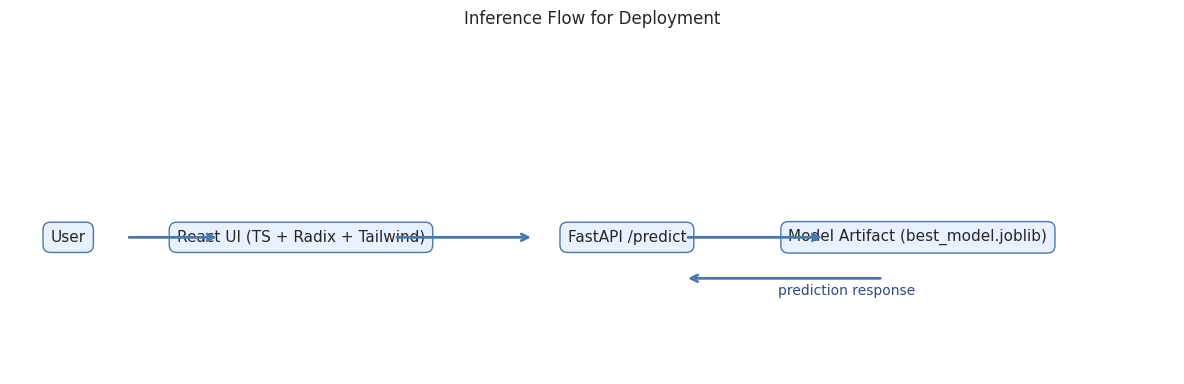

In [20]:
plt.figure(figsize=(12, 4))
plt.axis("off")

boxes = {
    "User": (0.05, 0.4),
    "React UI (TS + Radix + Tailwind)": (0.25, 0.4),
    "FastAPI /predict": (0.53, 0.4),
    "Model Artifact (best_model.joblib)": (0.78, 0.4),
}

for name, (x, y) in boxes.items():
    plt.text(
        x,
        y,
        name,
        ha="center",
        va="center",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.5", "facecolor": "#e8f1ff", "edgecolor": "#4c78a8"},
    )

arrow = dict(arrowstyle="->", lw=2, color="#4c78a8")
plt.annotate("", xy=(0.18, 0.4), xytext=(0.10, 0.4), arrowprops=arrow)
plt.annotate("", xy=(0.45, 0.4), xytext=(0.33, 0.4), arrowprops=arrow)
plt.annotate("", xy=(0.70, 0.4), xytext=(0.58, 0.4), arrowprops=arrow)
plt.annotate("", xy=(0.58, 0.28), xytext=(0.75, 0.28), arrowprops=arrow)
plt.text(0.66, 0.23, "prediction response", fontsize=10, color="#2f4b7c")

plt.title("Inference Flow for Deployment")
plt.tight_layout()
plt.show()

## 7) Storytelling: What Data to Collect for Next Training Iterations

**Why this step?**
Better future performance depends on richer clinical context, not only binary symptoms.

/tmp/ipykernel_1982977/2975922483.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=next_data_plan, x="Data Group", y="ValueScore", palette="Set2")


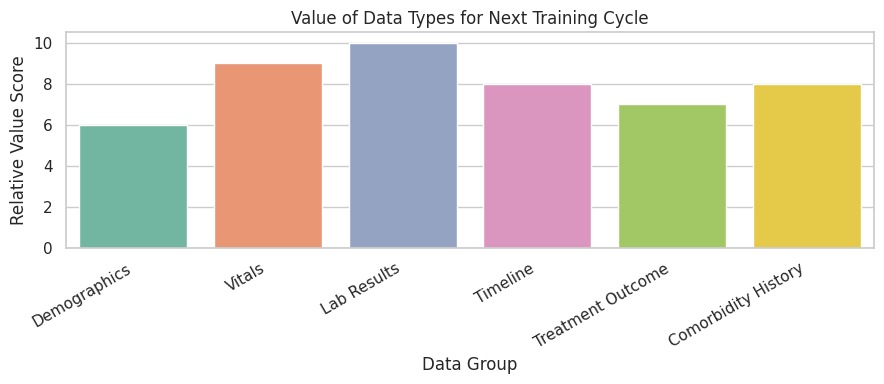

,Data Group,ValueScore
0,Demographics,6
1,Vitals,9
2,Lab Results,10
3,Timeline,8
4,Treatment Outcome,7
5,Comorbidity History,8


In [21]:
next_data_plan = pd.DataFrame(
    {
        "Data Group": [
            "Demographics",
            "Vitals",
            "Lab Results",
            "Timeline",
            "Treatment Outcome",
            "Comorbidity History",
        ],
        "ValueScore": [6, 9, 10, 8, 7, 8],
    }
)

plt.figure(figsize=(9, 4))
sns.barplot(data=next_data_plan, x="Data Group", y="ValueScore", palette="Set2")
plt.title("Value of Data Types for Next Training Cycle")
plt.xlabel("Data Group")
plt.ylabel("Relative Value Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

next_data_plan

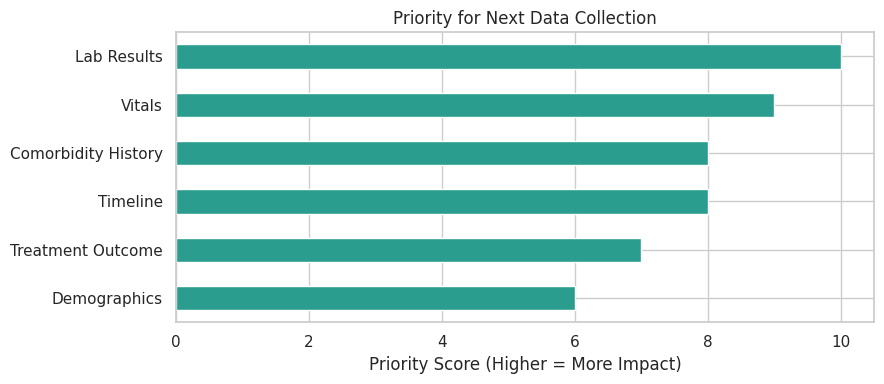

In [22]:
priority = pd.Series(
    {
        "Lab Results": 10,
        "Vitals": 9,
        "Comorbidity History": 8,
        "Timeline": 8,
        "Treatment Outcome": 7,
        "Demographics": 6,
    }
).sort_values()

plt.figure(figsize=(9, 4))
priority.plot(kind="barh", color="#2a9d8f")
plt.title("Priority for Next Data Collection")
plt.xlabel("Priority Score (Higher = More Impact)")
plt.tight_layout()
plt.show()